# Download data

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()

np.int64(11)

In [8]:
mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()
df[mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(df['TotalCharges'].isnull().sum())
print(df['TotalCharges'].dtype)

0
float64


In [10]:
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())

print("Fully duplicated rows:", df.duplicated().sum())

Duplicate customerIDs: 0
Fully duplicated rows: 0


In [11]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


# EDA

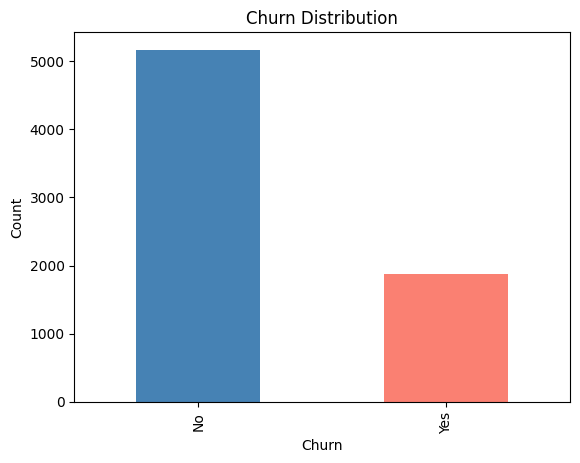

In [12]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

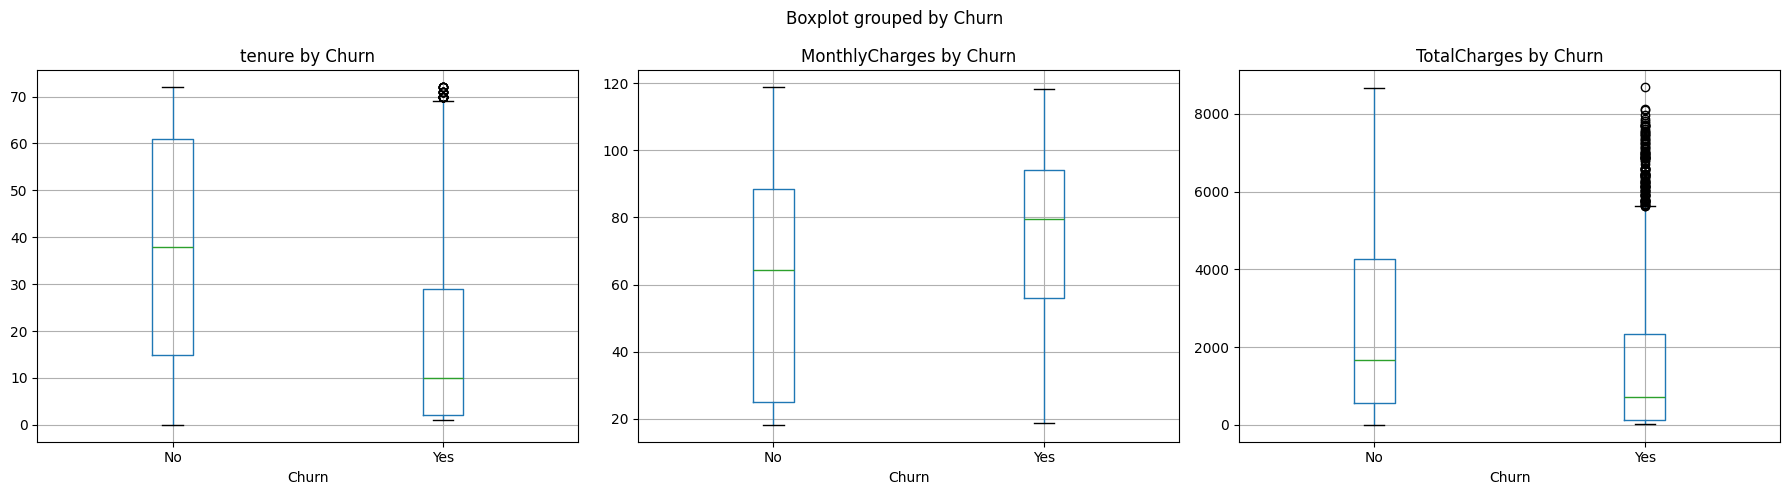

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    df.boxplot(column=col, by='Churn', ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel('Churn')

plt.tight_layout()
plt.show()

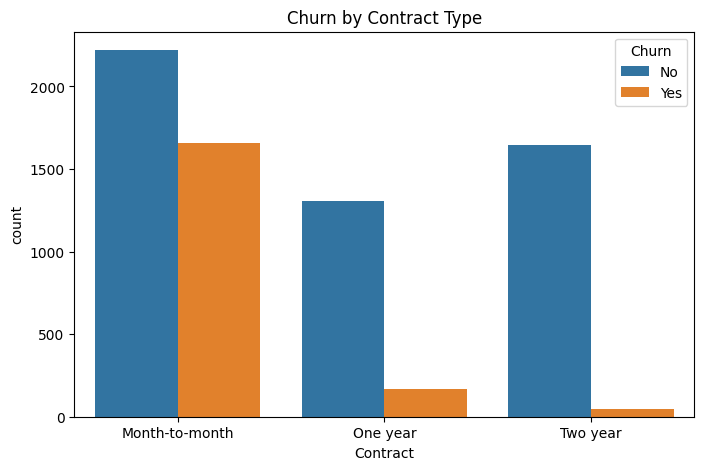

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [14]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.show()

# percentage
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

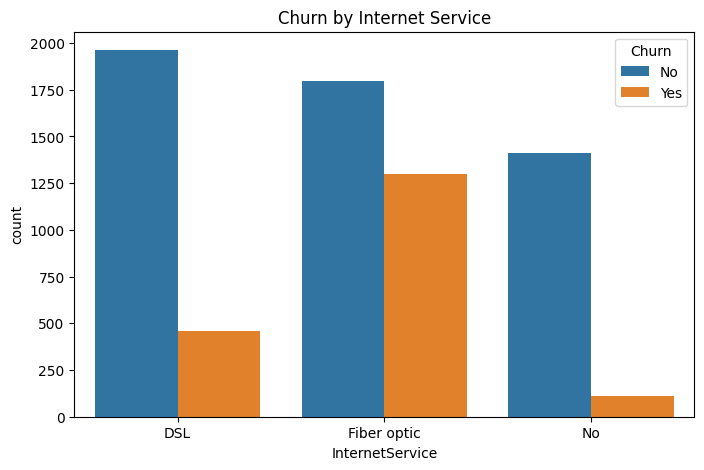

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service')
plt.show()

pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

In [16]:
df.groupby('InternetService')['MonthlyCharges'].mean()

,MonthlyCharges
InternetService,
DSL,58.102169
Fiber optic,91.500129
No,21.079194


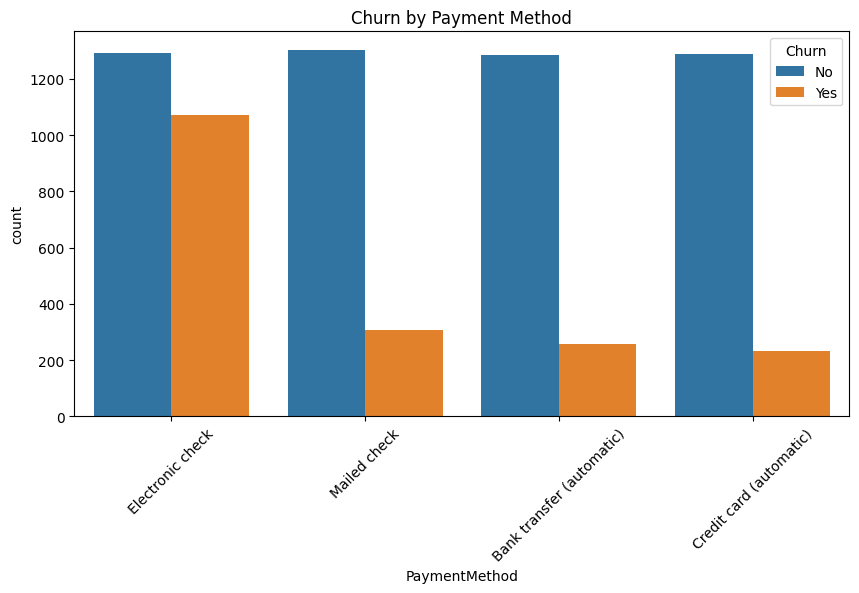

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [17]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=45)
plt.title('Churn by Payment Method')
plt.show()

pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

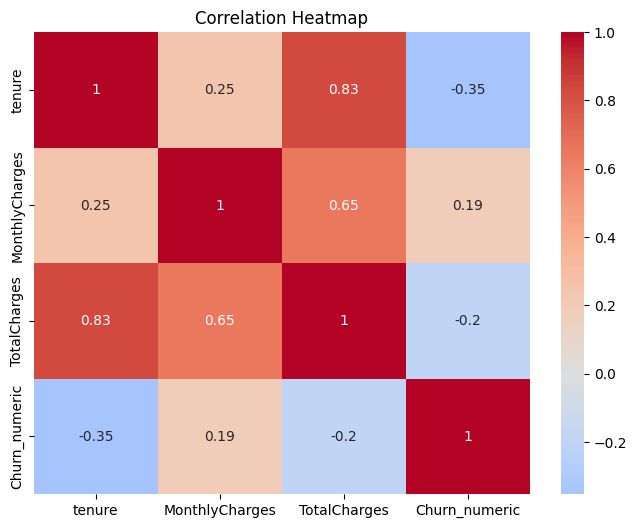

In [18]:
# نحول Churn مؤقتًا لأرقام (0/1) بس لغرض الـ heatmap دلوقتي، مش تعديل دائم على العمود
df_temp = df.copy()
df_temp['Churn_numeric'] = df_temp['Churn'].map({'No': 0, 'Yes': 1})

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']
plt.figure(figsize=(8,6))
sns.heatmap(df_temp[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# Encoding

In [19]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('customerID')  # ده هنشيله قبل الموديل مش دلوقتي، بس نستبعده من العد

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")
    print()

gender: ['Female' 'Male']

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn: ['No' 'Yes']



In [20]:
# الأعمدة اللي فيها "No internet service"
internet_related_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                          'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_related_cols:
    df[col] = df[col].replace('No internet service', 'No')

# نفس المنطق بالظبط لـ MultipleLines مع "No phone service"
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# نتأكد إن كل حاجة بقت Binary فعلاً
for col in internet_related_cols + ['MultipleLines']:
    print(f"{col}: {df[col].unique()}")

OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
MultipleLines: ['No' 'Yes']


In [21]:
# List of binary columns to convert to 0/1
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

# gender has Male/Female instead of Yes/No, handle separately
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# All other binary columns follow Yes/No pattern
for col in binary_cols:
    if col != 'gender':
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# Quick check
df[binary_cols].head()

,gender,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
0,0,1,0,0,0,0,1,0,0,0,0,1,0
1,1,0,0,1,0,1,0,1,0,0,0,0,0
2,1,0,0,1,0,1,1,0,0,0,0,1,1
3,1,0,0,0,0,1,0,1,1,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,1,1


In [22]:
from sklearn.preprocessing import OrdinalEncoder

# Define the logical order explicitly
contract_order = [['Month-to-month', 'One year', 'Two year']]

encoder = OrdinalEncoder(categories=contract_order)
df['Contract'] = encoder.fit_transform(df[['Contract']])

df['Contract'].unique()

array([0., 1., 2.])

In [23]:
df = pd.get_dummies(df, columns=['InternetService', 'PaymentMethod'], drop_first=True)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,0,0,1,...,0.0,1,29.85,29.85,0,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,1,0,...,1.0,0,56.95,1889.50,0,False,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,...,0.0,1,53.85,108.15,1,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,1,0,...,1.0,0,42.30,1840.75,0,False,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,0,0,0,...,0.0,1,70.70,151.65,1,True,False,False,True,False


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   int64  
 7   MultipleLines                          7043 non-null   int64  
 8   OnlineSecurity                         7043 non-null   int64  
 9   OnlineBackup                           7043 non-null   int64  
 10  DeviceProtection                       7043 non-null   int64  
 11  Tech

In [25]:
# Check statistical summary for potential data entry errors
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


# Train-Test Split

In [26]:
# Drop customerID (no predictive value) and separate features from target
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 22)
y shape: (7043,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Ensures same Churn ratio in train and test sets
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()
print("Train Churn ratio:\n", y_train.value_counts(normalize=True))
print()
print("Test Churn ratio:\n", y_test.value_counts(normalize=True))

Train shape: (5634, 22)
Test shape: (1409, 22)

Train Churn ratio:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test Churn ratio:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


# Feature scaling

In [28]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data only, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability (optional but helpful)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,...,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03,5.634000e+03
mean,1.135052e-16,7.440898e-17,-7.031018e-17,2.900689e-17,-1.008935e-17,-2.679985e-18,-2.522338e-18,2.143988e-17,2.774572e-17,3.783508e-18,...,5.927495e-17,2.396222e-17,3.941154e-17,-2.402527e-16,2.522338e-17,-4.287975e-17,-7.724661e-17,-4.287975e-17,-3.279040e-17,-2.017871e-17
std,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,...,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.005696e+00,-4.417730e-01,-9.692341e-01,-6.515565e-01,-1.322329e+00,-3.013090e+00,-8.583384e-01,-6.361110e-01,-7.355464e-01,-7.269705e-01,...,-8.013032e-01,-8.277744e-01,-1.202653e+00,-1.544028e+00,-1.008922e+00,-8.876958e-01,-5.240808e-01,-5.238056e-01,-7.107811e-01,-5.438457e-01
25%,-1.005696e+00,-4.417730e-01,-9.692341e-01,-6.515565e-01,-9.559779e-01,3.318852e-01,-8.583384e-01,-6.361110e-01,-7.355464e-01,-7.269705e-01,...,-8.013032e-01,-8.277744e-01,-1.202653e+00,-9.711977e-01,-8.321009e-01,-8.876958e-01,-5.240808e-01,-5.238056e-01,-7.107811e-01,-5.438457e-01
50%,9.943362e-01,-4.417730e-01,-9.692341e-01,-6.515565e-01,-1.418632e-01,3.318852e-01,-8.583384e-01,-6.361110e-01,-7.355464e-01,-7.269705e-01,...,-8.013032e-01,-8.277744e-01,8.314950e-01,1.848336e-01,-3.968446e-01,-8.876958e-01,-5.240808e-01,-5.238056e-01,-7.107811e-01,-5.438457e-01
75%,9.943362e-01,-4.417730e-01,1.031742e+00,1.534786e+00,9.164859e-01,3.318852e-01,1.165042e+00,1.572053e+00,1.359534e+00,1.375572e+00,...,1.247967e+00,3.708072e-01,8.314950e-01,8.319124e-01,6.741944e-01,1.126512e+00,-5.240808e-01,-5.238056e-01,1.406903e+00,-5.438457e-01
max,9.943362e-01,2.263606e+00,1.031742e+00,1.534786e+00,1.608483e+00,3.318852e-01,1.165042e+00,1.572053e+00,1.359534e+00,1.375572e+00,...,1.247967e+00,1.569389e+00,8.314950e-01,1.785939e+00,2.801869e+00,1.126512e+00,1.908103e+00,1.909105e+00,1.406903e+00,1.838757e+00


# Baseline Model: Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Train on scaled data
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predict
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
 [[926 109]
 [164 210]]
ROC-AUC Score: 0.8421039034849778


# KNN

In [30]:
from sklearn.neighbors import KNeighborsClassifier

# KNN needs scaled data (distance-based, remember?)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_pred_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_knn))

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.83      1035
           1       0.54      0.51      0.52       374

    accuracy                           0.75      1409
   macro avg       0.68      0.67      0.68      1409
weighted avg       0.75      0.75      0.75      1409

Confusion Matrix:
 [[873 162]
 [185 189]]
ROC-AUC Score: 0.7703492727789403


# Naive Bayes

In [31]:
from sklearn.naive_bayes import GaussianNB

# Naive Bayes doesn't need scaling, but scaled data won't hurt it either
# We'll use the original (unscaled) data since GaussianNB works with raw distributions
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
y_pred_proba_nb = nb.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_nb))

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.75      0.82      1035
           1       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409

Confusion Matrix:
 [[779 256]
 [ 97 277]]
ROC-AUC Score: 0.8232814074246297


# Decision Tree

In [32]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree doesn't need scaling (splits aren't affected by feature magnitude)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_pred_proba_dt = dt.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_dt))

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.82      1035
           1       0.51      0.53      0.52       374

    accuracy                           0.74      1409
   macro avg       0.67      0.68      0.67      1409
weighted avg       0.74      0.74      0.74      1409

Confusion Matrix:
 [[844 191]
 [174 200]]
ROC-AUC Score: 0.6746596398770311


## compare between train and test data to make sure if overfitting happened

In [33]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, dt.predict(X_train))
test_acc = accuracy_score(y_test, dt.predict(X_test))

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.9980
Test Accuracy: 0.7410


## Limit tree depth to reduce overfitting


In [34]:
# Limit tree depth to reduce overfitting
dt_limited = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
dt_limited.fit(X_train, y_train)

train_acc_limited = accuracy_score(y_train, dt_limited.predict(X_train))
test_acc_limited = accuracy_score(y_test, dt_limited.predict(X_test))

print(f"Train Accuracy (limited): {train_acc_limited:.4f}")
print(f"Test Accuracy (limited): {test_acc_limited:.4f}")
print()

y_pred_dt_limited = dt_limited.predict(X_test)
y_pred_proba_dt_limited = dt_limited.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_dt_limited))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_dt_limited))

Train Accuracy (limited): 0.8028
Test Accuracy (limited): 0.7991

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.63      0.58      0.61       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.79      0.80      0.80      1409

ROC-AUC Score: 0.8312330465783152


# SVM

In [35]:
from sklearn.svm import SVC

# SVM needs scaled data (distance/margin-based, remember?)
# probability=True is required to get predict_proba for ROC-AUC
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_pred_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_svm))

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix:
 [[932 103]
 [193 181]]
ROC-AUC Score: 0.7901211604536413


# Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest doesn't need scaling (tree-based, same as Decision Tree)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_rf))

# Check overfitting too, same as we did with Decision Tree
train_acc_rf = accuracy_score(y_train, rf.predict(X_train))
test_acc_rf = accuracy_score(y_test, rf.predict(X_test))
print(f"\nTrain Accuracy: {train_acc_rf:.4f}")
print(f"Test Accuracy: {test_acc_rf:.4f}")

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
 [[931 104]
 [179 195]]
ROC-AUC Score: 0.8250277713193315

Train Accuracy: 0.9980
Test Accuracy: 0.7991


## use Regularization to reduce overfitting

In [37]:
rf_limited = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42
)
rf_limited.fit(X_train, y_train)

train_acc_rf_limited = accuracy_score(y_train, rf_limited.predict(X_train))
test_acc_rf_limited = accuracy_score(y_test, rf_limited.predict(X_test))
print(f"Train Accuracy (limited): {train_acc_rf_limited:.4f}")
print(f"Test Accuracy (limited): {test_acc_rf_limited:.4f}")
print()

y_pred_rf_limited = rf_limited.predict(X_test)
y_pred_proba_rf_limited = rf_limited.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_rf_limited))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_rf_limited))

Train Accuracy (limited): 0.8177
Test Accuracy (limited): 0.8013

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.49      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC Score: 0.8480069234544937


# XGBoost

In [38]:
from xgboost import XGBClassifier

# XGBoost doesn't need scaling (tree-based)
xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_xgb))

# Check overfitting
train_acc_xgb = accuracy_score(y_train, xgb.predict(X_train))
test_acc_xgb = accuracy_score(y_test, xgb.predict(X_test))
print(f"\nTrain Accuracy: {train_acc_xgb:.4f}")
print(f"Test Accuracy: {test_acc_xgb:.4f}")

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
 [[925 110]
 [171 203]]
ROC-AUC Score: 0.8426606215608773

Train Accuracy: 0.8490
Test Accuracy: 0.8006


# class_weight='balanced'

In [39]:
# class_weight='balanced' automatically adjusts weights inversely proportional to class frequencies
log_reg_weighted = LogisticRegression(class_weight='balanced', random_state=42)
log_reg_weighted.fit(X_train_scaled, y_train)

y_pred_weighted = log_reg_weighted.predict(X_test_scaled)
y_pred_proba_weighted = log_reg_weighted.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression with class_weight='balanced' ===")
print("Classification Report:\n", classification_report(y_test, y_pred_weighted))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_weighted))

=== Logistic Regression with class_weight='balanced' ===
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score: 0.8414270583068537


# SMOTE

In [40]:
# Need to install if not available
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

# Apply SMOTE ONLY on training data (never on test data!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

log_reg_smote = LogisticRegression(random_state=42)
log_reg_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = log_reg_smote.predict(X_test_scaled)
y_pred_proba_smote = log_reg_smote.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression with SMOTE ===")
print("Classification Report:\n", classification_report(y_test, y_pred_smote))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_smote))

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}

=== Logistic Regression with SMOTE ===
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score: 0.8408457981348005


# Feature Importance

In [41]:
import numpy as np

# Get feature names and their coefficients
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_reg_smote.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(feature_importance.head(10))

                        feature  coefficient
4                        tenure    -1.409092
15               MonthlyCharges    -0.886369
16                 TotalCharges     0.767673
17  InternetService_Fiber optic     0.723968
13                     Contract    -0.654614
18           InternetService_No    -0.588581
12              StreamingMovies     0.284472
11                  StreamingTV     0.232318
14             PaperlessBilling     0.213802
6                 MultipleLines     0.201005


## solve multicollinearity

In [42]:
# Drop TotalCharges since it's highly correlated with tenure (0.83)
# and largely derivable from tenure * MonthlyCharges
X_train_v2 = X_train.drop('TotalCharges', axis=1)
X_test_v2 = X_test.drop('TotalCharges', axis=1)

# Re-scale after dropping the column
scaler_v2 = StandardScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled = scaler_v2.transform(X_test_v2)

# Re-apply SMOTE on the new feature set
X_train_v2_smote, y_train_v2_smote = smote.fit_resample(X_train_v2_scaled, y_train)

# Retrain Logistic Regression
log_reg_v2 = LogisticRegression(random_state=42)
log_reg_v2.fit(X_train_v2_smote, y_train_v2_smote)

y_pred_v2 = log_reg_v2.predict(X_test_v2_scaled)
y_pred_proba_v2 = log_reg_v2.predict_proba(X_test_v2_scaled)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred_v2))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_v2))

# Check the new coefficients
feature_importance_v2 = pd.DataFrame({
    'feature': X_train_v2.columns,
    'coefficient': log_reg_v2.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\n", feature_importance_v2.head(10))

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.76      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409

ROC-AUC Score: 0.8371567335761709

                            feature  coefficient
4                           tenure    -0.788263
16     InternetService_Fiber optic     0.717298
13                        Contract    -0.663397
15                  MonthlyCharges    -0.599569
17              InternetService_No    -0.489179
12                 StreamingMovies     0.289804
11                     StreamingTV     0.224511
6                    MultipleLines     0.217944
14                PaperlessBilling     0.208805
19  PaymentMethod_Electronic check     0.185567


### ## Experiment: Removing TotalCharges (Multicollinearity Check)
Tested removing TotalCharges to address multicollinearity with tenure (corr=0.83).
Result: Performance slightly decreased (F1: 0.62 → 0.61, ROC-AUC: 0.841 → 0.837)
and MonthlyCharges coefficient remained negative despite removal — suggesting
the multicollinearity involves multiple features, not just TotalCharges alone.
Decision: Keep TotalCharges in the final model. Document tenure, MonthlyCharges,
and TotalCharges as a correlated group when interpreting coefficients, rather
than treating each in isolation.

In [43]:
# ============================================
# FINAL MODEL: Logistic Regression + SMOTE
# (Reverting to full feature set including TotalCharges,
# since removing it did not improve performance)
# ============================================

# Final scaler and SMOTE already computed earlier as:
# X_train_scaled, X_test_scaled, X_train_smote, y_train_smote

final_model = LogisticRegression(random_state=42)
final_model.fit(X_train_smote, y_train_smote)

y_pred_final = final_model.predict(X_test_scaled)
y_pred_proba_final = final_model.predict_proba(X_test_scaled)[:, 1]

print("=== FINAL MODEL: Logistic Regression + SMOTE ===")
print("Classification Report:\n", classification_report(y_test, y_pred_final))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_final))

=== FINAL MODEL: Logistic Regression + SMOTE ===
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Confusion Matrix:
 [[742 293]
 [ 75 299]]
ROC-AUC Score: 0.8408457981348005


# Telco Customer Churn — Project Summary

## 1. Problem Statement
Binary classification task to predict customer churn for a telecom company,
enabling proactive retention strategies for at-risk customers.

## 2. Data Cleaning
- Discovered 11 hidden missing values in `TotalCharges` (stored as whitespace
  strings, masked from `.info()`'s null check)
- All 11 rows had `tenure=0` (new customers with no billing history yet) →
  filled with 0 logically, not with mean/median
- No duplicate rows or customer IDs found

## 3. EDA — Key Insights
- **Class imbalance:** 73.5% No Churn vs 26.5% Yes Churn (moderate imbalance)
- **Contract type** is the strongest predictor: Month-to-month customers churn
  at 42.7% vs 2.8% for Two-year contracts
- **Payment method:** Electronic check users churn at 45.3%, far higher than
  automatic payment methods (~15-17%)
- **Fiber optic** internet users churn more (41.9%), largely confounded with
  higher average monthly price (91.5 vs 58.1 for DSL)
- **Low tenure + high MonthlyCharges** combination = highest churn risk
- Detected multicollinearity between `tenure`, `MonthlyCharges`, and
  `TotalCharges` (up to 0.83 correlation)

## 4. Feature Engineering
- Consolidated redundant categories ("No internet service" / "No phone
  service") into "No" across 7 columns
- Binary encoding for Yes/No columns
- Ordinal encoding for `Contract` (respects Month-to-month < One year < Two year)
- One-Hot encoding for `InternetService` and `PaymentMethod` (nominal, no order)

## 5. Modeling — Results Summary

| Model | ROC-AUC | F1 (Churn) | Recall (Churn) | Precision (Churn) |
|---|---|---|---|---|
| Logistic Regression | 0.842 | 0.61 | 0.56 | 0.66 |
| KNN | 0.770 | 0.52 | 0.51 | 0.54 |
| Naive Bayes | 0.823 | 0.61 | 0.74 | 0.52 |
| Decision Tree (tuned) | 0.831 | 0.61 | 0.58 | 0.63 |
| SVM | 0.790 | 0.55 | 0.48 | 0.64 |
| Random Forest (tuned) | 0.848 | 0.57 | 0.49 | 0.67 |
| XGBoost | 0.843 | 0.59 | 0.54 | 0.65 |
| **Logistic Regression + SMOTE (Final)** | **0.841** | **0.62** | **0.80** | 0.51 |

**Overfitting was identified and corrected** in Decision Tree (train/test gap:
25.7% → 0.4%) and Random Forest (19.9% → 1.6%) via `max_depth` and
`min_samples_leaf` tuning.

## 6. Handling Imbalance
Compared `class_weight='balanced'` vs SMOTE on Logistic Regression. SMOTE gave
the best F1 (0.62) and highest Recall (0.80) — critical for the business goal
of catching as many at-risk customers as possible.

## 7. Final Model: Logistic Regression + SMOTE
**Selection criteria:** F1-score as primary metric (balances catching real
churners vs. wasting retention budget on false alarms), ROC-AUC as tie-breaker,
plus interpretability advantage over tree ensembles.

**Attempted fix for multicollinearity** (dropping `TotalCharges`): tested but
reverted — performance slightly decreased (F1: 0.62→0.61) and did not fully
resolve the interpretability issue (MonthlyCharges coefficient stayed negative).
Documented `tenure`, `MonthlyCharges`, and `TotalCharges` as a correlated group
rather than interpreting each coefficient in isolation.

## 8. Top Predictive Features (Logistic Regression coefficients)
1. `tenure` (-1.41) — strongest predictor, longer tenure = lower churn
2. `MonthlyCharges` (-0.89) — affected by multicollinearity, interpret with caution
3. `TotalCharges` (+0.77) — affected by multicollinearity, interpret with caution
4. `InternetService_Fiber optic` (+0.72) — confirms EDA finding
5. `Contract` (-0.65) — confirms EDA's strongest categorical insight

## 9. Business Recommendations
- Target retention campaigns at Month-to-month, Electronic check customers
  with low tenure
- Investigate why Fiber optic churns more — price sensitivity or service
  quality issue
- Consider incentivizing longer contract commitments to reduce churn risk